### 📌 Anomaly Score Formula

For a data point 
𝑥
x:

𝑠
(
𝑥
,
𝑛
)
=
2
−
𝐸
(
ℎ
(
𝑥
)
)
𝑐
(
𝑛
)
s(x,n)=2
−
c(n)
E(h(x))
	​


where:

𝐸
(
ℎ
(
𝑥
)
)
E(h(x)) = average path length of 
𝑥
x in isolation trees

𝑛
n = number of samples

𝑐
(
𝑛
)
c(n) = normalization factor (built using harmonic numbers)

-------------------------------------------------------

### 📌 Normalization Term using Harmonic Number
𝑐
(
𝑛
)
=
2
𝐻
(
𝑛
−
1
)
−
2
(
𝑛
−
1
)
𝑛
c(n)=2H(n−1)−
n
2(n−1)
	​


Here:

𝐻
(
𝑛
−
1
)
=
1
+
1
2
+
1
3
+
⋯
+
1
𝑛
−
1
H(n−1)=1+
2
1
	​

+
3
1
	​

+⋯+
n−1
1
	​


is the harmonic number.

---------------------------------------------------------

🎯 Interpretation of Score

𝑠
(
𝑥
)
≈
1
s(x)≈1 → strong anomaly

𝑠
(
𝑥
)
≈
0.5
s(x)≈0.5 → normal

𝑠
(
𝑥
)
<
0.5
s(x)<0.5 → very normal

Reason:
Anomalies get isolated quickly → shorter path → higher score.

-----------------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [7]:
air_quality = fetch_ucirepo(id = 360)
air_quality

{'data': {'ids': None,
  'features':            Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
  0     3/10/2004  18:00:00     2.6         1360       150      11.9   
  1     3/10/2004  19:00:00     2.0         1292       112       9.4   
  2     3/10/2004  20:00:00     2.2         1402        88       9.0   
  3     3/10/2004  21:00:00     2.2         1376        80       9.2   
  4     3/10/2004  22:00:00     1.6         1272        51       6.5   
  ...         ...       ...     ...          ...       ...       ...   
  9352   4/4/2005  10:00:00     3.1         1314      -200      13.5   
  9353   4/4/2005  11:00:00     2.4         1163      -200      11.4   
  9354   4/4/2005  12:00:00     2.4         1142      -200      12.4   
  9355   4/4/2005  13:00:00     2.1         1003      -200       9.5   
  9356   4/4/2005  14:00:00     2.2         1071      -200      11.9   
  
        PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  \
  0              1046      

In [12]:
data = pd.DataFrame(air_quality.data.features)
data

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [16]:
data.size

140355

In [15]:
data.shape

(9357, 15)

## Data Preprocessing steps

In [11]:
df = data[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]
df.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116


In [18]:
df.shape

(9357, 4)

In [19]:
df.size

37428

In [26]:
# parameters for isolation forest

n_estimators = 100  ## Number of trees in the forest
contamination = 0.01
sample_size = 256

In [28]:
# Train the isolation forest model

from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators = n_estimators, 
contamination = contamination, max_samples = sample_size,
random_state = 42)

In [29]:
model.fit(df)

# Predict anamaolies
anomaly_labels = model.predict(df)

# Add anamaly llabels to the DataFrame
df['anomaly'] = anomaly_labels

In [30]:
df.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1


In [31]:
df['anomaly'].value_counts()

anomaly
 1    9263
-1      94
Name: count, dtype: int64

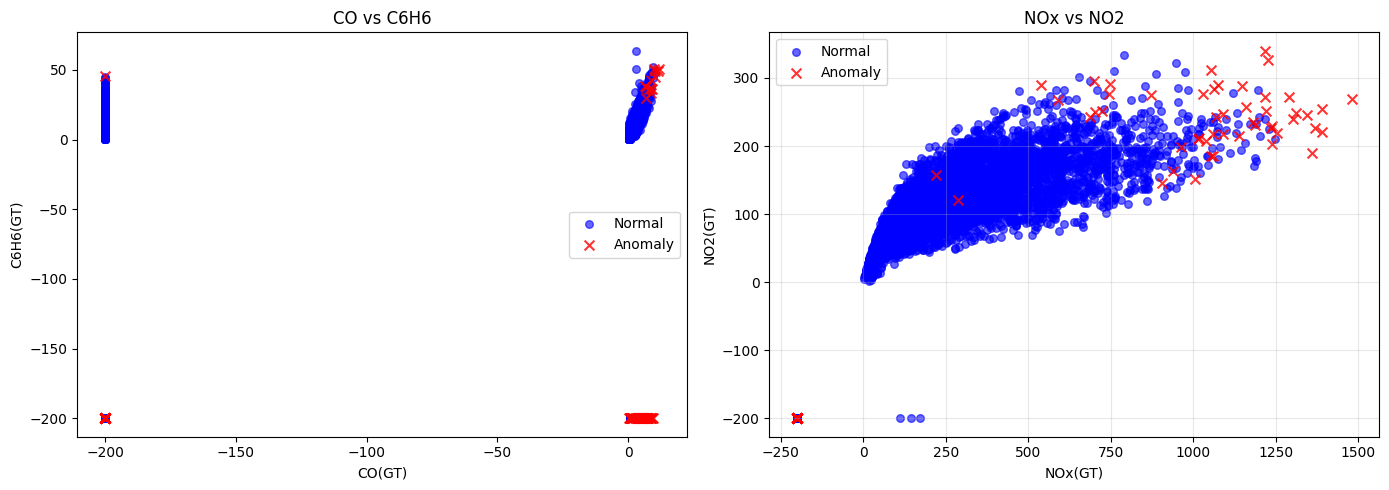

In [ ]:
# Visualize anomalies - Multiple feature comparisons
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal = df[df['anomaly' ] == 1]
anomaly = df[df['anomaly' ] == -1]

# Plot 1: CO vs C6H6
axes[0].scatter(normal['CO(GT)'], normal['C6H6(GT)'], color='blue',
label='Normal', alpha=0.6, s=30)
axes[0].scatter(anomaly['CO(GT)'], anomaly['C6H6(GT)'], color='red',
label='Anomaly', alpha=0.8, s=50, marker='x')
axes[0].set_xlabel('CO(GT)')
axes[0].set_ylabel('C6H6(GT)')
axes[0].set_title('CO vs C6H6')
axes[0].legend ()

# Plot 2: NOX VS NO2
axes[1].scatter(normal['NOx(GT)'], normal['NO2(GT)'], color='blue',
label='Normal', alpha=0.6, s=30)
axes[1].scatter(anomaly['NOx(GT)'], anomaly['NO2(GT)'], color='red',
label='Anomaly', alpha=0.8, s=50, marker='x')
axes[1].set_xlabel('NOx(GT)')
axes[1].set_ylabel('NO2(GT)')
axes[1].set_title('NOx vs NO2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
print(f"Normal data points: {len(normal)}")
print(f"Anomalies detected: {len(anomaly)}")

Normal data points: 9263
Anomalies detected: 94


In [ ]:
# saved model
import joblib

joblib.dump(model, 'isolation_forest_air_quality.pkl')

['isolation_forest_air_quality.pkl']